Data loaded: (4877, 108) rows, 108 columns

Columns with missing values:
reporting_level                              466
welfare_type                                 466
survey_year                                  466
survey_comparability                         466
headcount_ratio_40_median                    466
headcount_ratio_50_median                    466
headcount_ratio_60_median                    466
headcount_40_median                          466
headcount_50_median                          466
headcount_60_median                          466
avg_shortfall_international_povline          291
avg_shortfall_lower_mid_income_povline       100
avg_shortfall_upper_mid_income_povline        12
avg_shortfall_100                            750
avg_shortfall_1000                             6
avg_shortfall_40_median                      468
avg_shortfall_50_median                      466
avg_shortfall_60_median                      466
total_shortfall_40_median                    

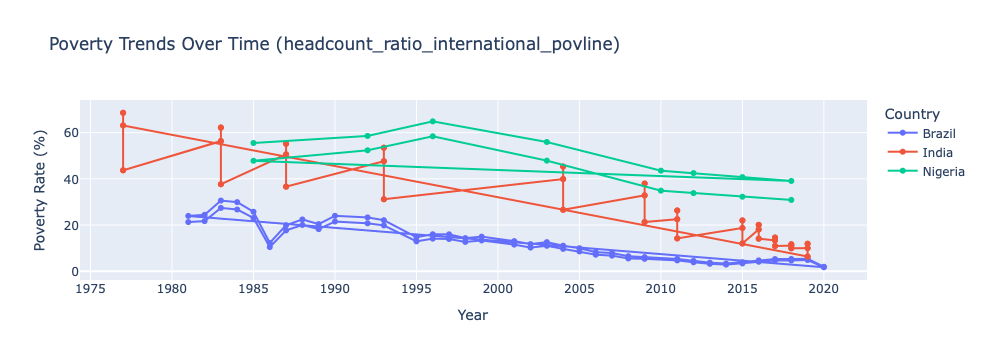

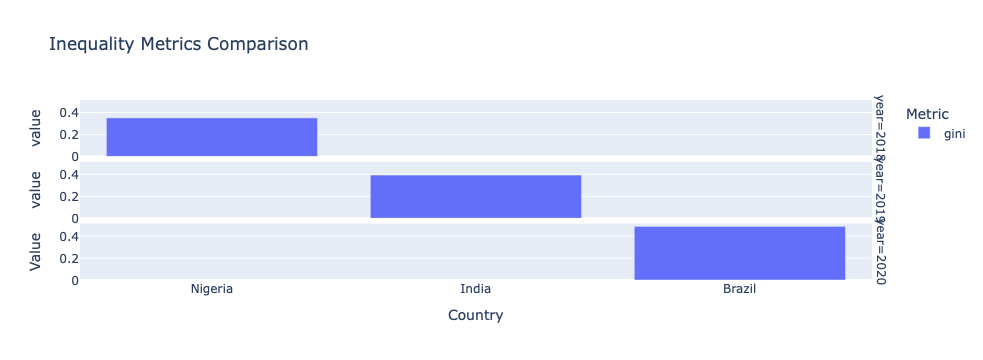

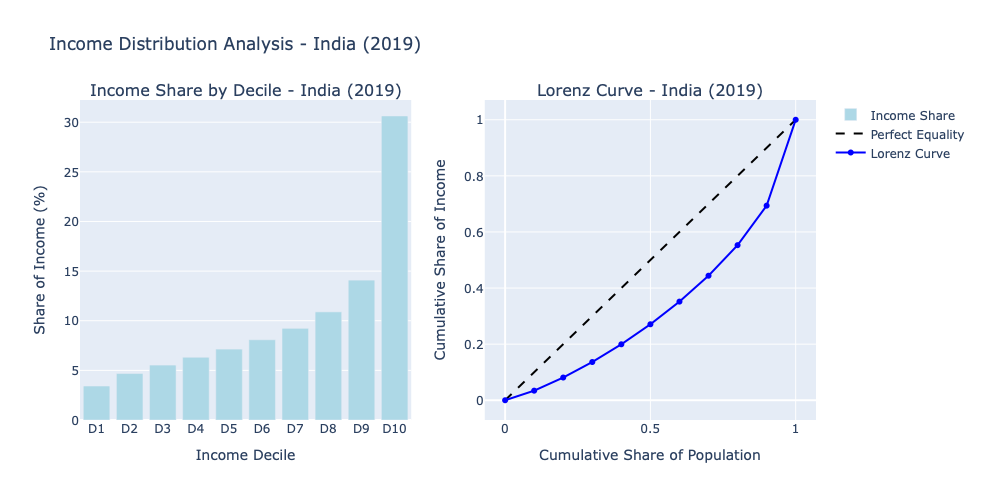


Inequality metrics for India (2019):
gini: 0.3573
palma_ratio: 1.5351
s80_s20_ratio: 5.5202
p90_p10_ratio: 4.0789
mld: 0.2101
polarization: 0.2661


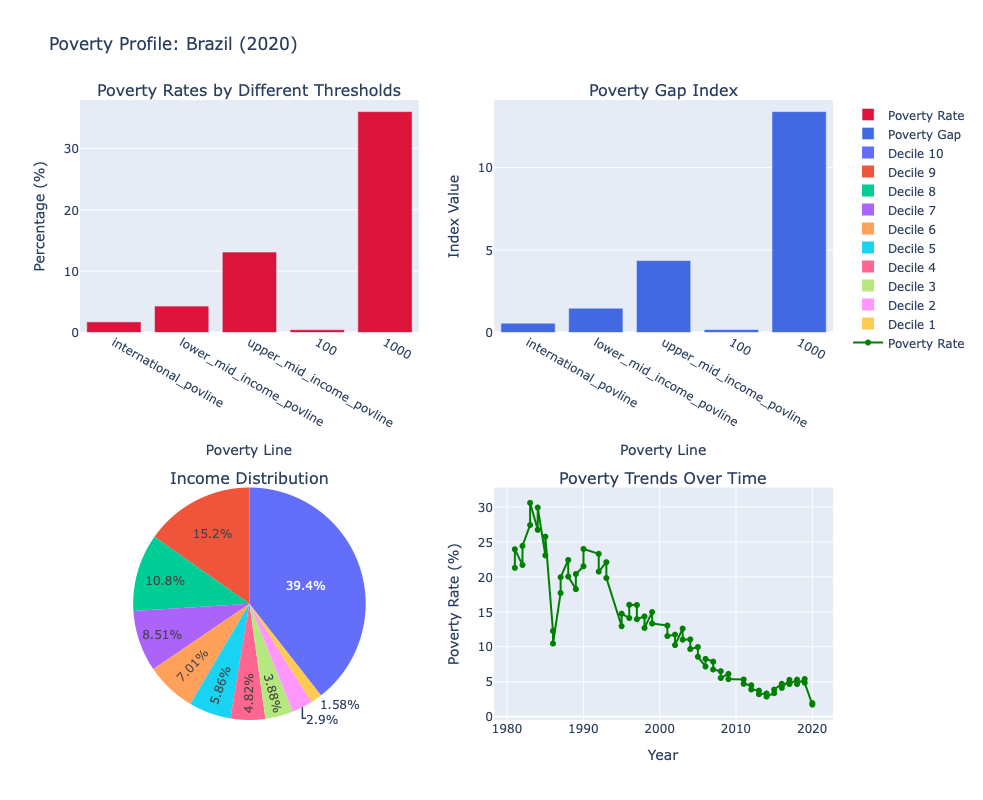


Poverty Profile Summary for Brazil (2020):
International Poverty Rate: 1.73%
Gini Coefficient: 0.4888
Mean Income/Consumption: 20.31
Median Income/Consumption: 13.02
India: Annual rate of change = -5.31% over 42 years
Brazil: Annual rate of change = -5.95% over 39 years
Nigeria: Annual rate of change = -1.76% over 33 years


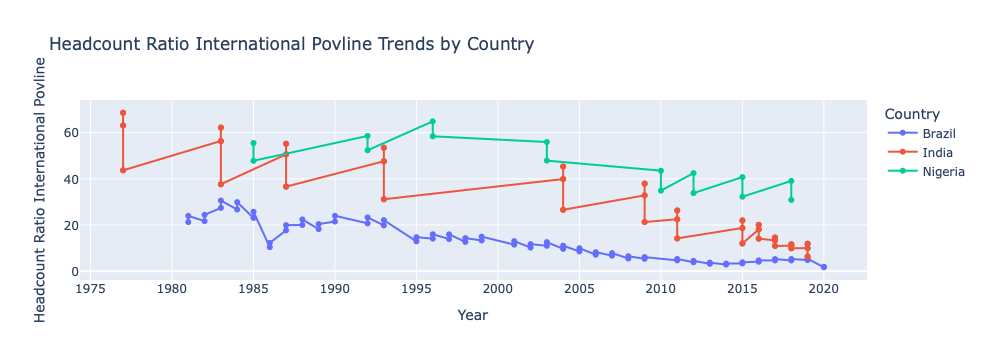

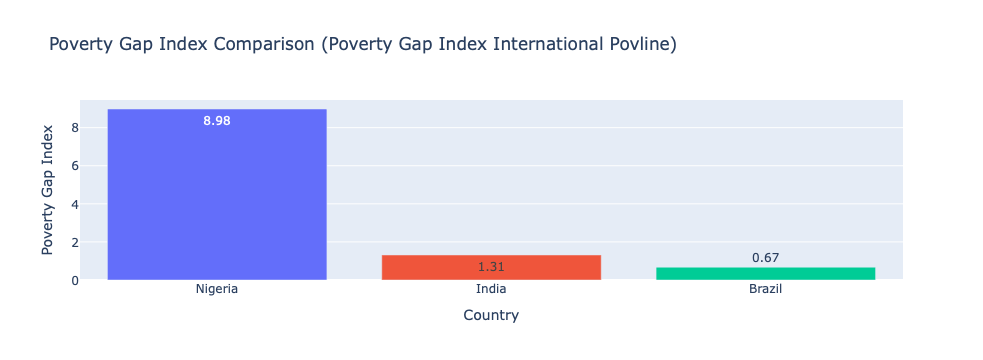


Poverty Gap Analysis (Poverty Gap Index International Povline):
      country  year  poverty_gap_index_international_povline
4054  Nigeria  2018                                 8.979669
3461    India  2019                                 1.313507
2691   Brazil  2020                                 0.670181


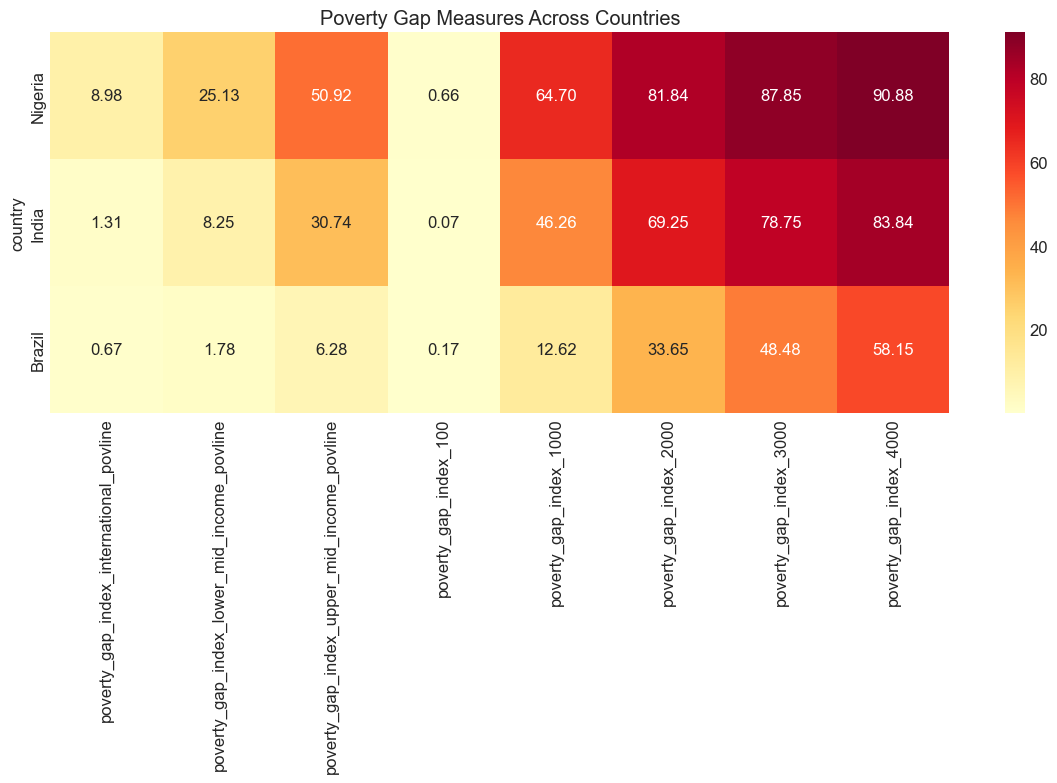

Silhouette Score: 0.5323


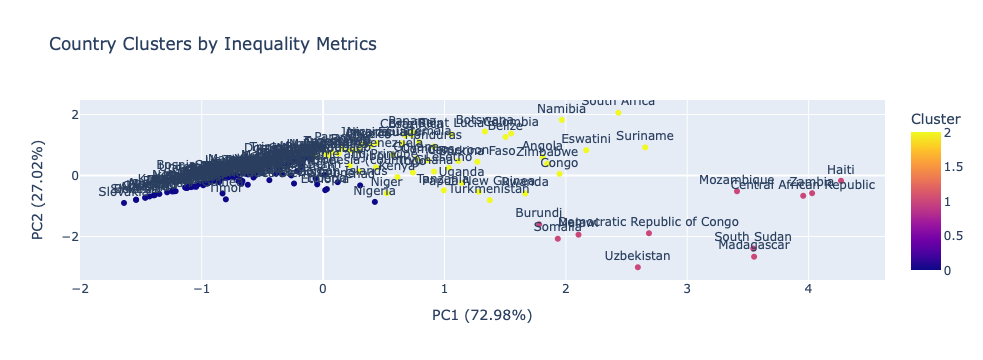


Cluster Characteristics:
             gini  poverty_gap_index_international_povline
Cluster                                                   
0        0.329838                                 1.027391
1        0.460279                                33.134097
2        0.462852                                 6.119112

Cluster 0 Countries (110):
Trinidad and Tobago, Syria, Azerbaijan, Jordan, Nepal, Tuvalu, Lebanon, Bosnia and Herzegovina, Algeria, Iraq, Nauru, Solomon Islands, United Arab Emirates, Samoa, Japan, Morocco, Mauritania, Timor, Yemen, Sudan, Tajikistan, Gambia, Ethiopia, Tunisia, Tonga, South Korea, Taiwan, Sri Lanka, Bangladesh, Palestine, Liberia, Egypt, United Kingdom, Iceland, Gabon, Mauritius, Kosovo, Canada, Bhutan, Myanmar, Chad, Guinea-Bissau, Switzerland, Guinea, Pakistan, France, Laos, Sierra Leone, Benin, Mali, Cote d'Ivoire, Senegal, Ireland, Italy, Mongolia, Montenegro, Seychelles, Germany, Philippines, Israel, North Macedonia, Australia, Kazakhstan, Nigeria,

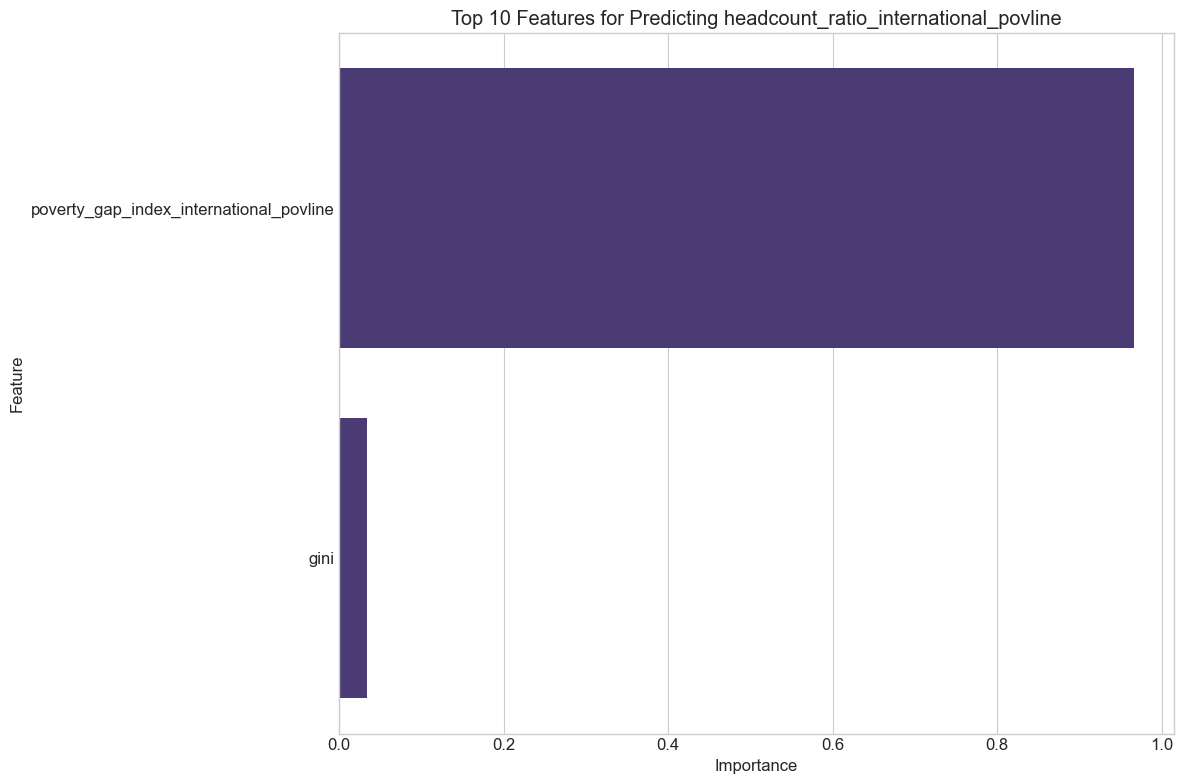

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, classification_report, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set better aesthetics for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

class PovertyAnalysis:
    """
    A comprehensive class for analyzing poverty and inequality data.
    """
    def __init__(self):
        self.data = None
        self.models = {}
        self.clusters = None
        self.scaler = StandardScaler()
        
    def load_data(self, file_path=None, data=None, separator='\t'):
        """
        Load poverty and inequality data from file or directly from a dataframe.
        
        Parameters:
        file_path (str): Path to the data file
        data (pd.DataFrame): Dataframe containing the data
        separator (str): Delimiter in the file
        """
        if data is not None:
            self.data = data
        elif file_path is not None:
            try:
                self.data = pd.read_csv(file_path, sep=separator)
                print(f"Data loaded: {self.data.shape} rows, {self.data.shape[1]} columns")
            except Exception as e:
                print(f"Error loading data: {e}")
                return None
        else:
            print("Please provide either a file path or a dataframe.")
            return None
        
        # Initial data cleaning and preprocessing
        self._clean_data()
        
        return self.data
    
    def _clean_data(self):
        """
        Clean and preprocess the loaded data.
        """
        if self.data is None:
            raise ValueError("No data loaded. Call load_data() first.")
        
        # Check for missing values
        missing_values = self.data.isnull().sum()
        print("\nColumns with missing values:")
        print(missing_values[missing_values > 0])

        # Print data information
        print("\nData types:")
        print(self.data.dtypes)
        
        # Convert appropriate columns to numeric
        numeric_columns = self.data.columns[~self.data.columns.isin(['country', 'reporting_level', 'welfare_type', 'ppp_version'])]
        for col in numeric_columns:
            try:
                self.data[col] = pd.to_numeric(self.data[col], errors='coerce')
            except:
                pass
        
        print("\nSample data:")
        print(self.data.head())
        
        # Summary statistics
        print("\nSummary statistics for key poverty indicators:")
        key_indicators = [col for col in self.data.columns if 'headcount_ratio' in col][:5]  # Limit to first 5
        print(self.data[key_indicators].describe())
        
        # Count unique countries and years
        if 'country' in self.data.columns:
            print(f"\nNumber of countries: {self.data['country'].nunique()}")
            print(f"Countries: {sorted(self.data['country'].unique())}")
        
        if 'year' in self.data.columns:
            print(f"\nYear range: {self.data['year'].min()} - {self.data['year'].max()}")
            print(f"Number of years: {self.data['year'].nunique()}")
        
    def visualize_poverty_trends(self, countries=None, poverty_indicator='headcount_ratio_international_povline'):
        """
        Visualize poverty trends over time for selected countries.
        
        Parameters:
        countries (list): List of countries to visualize, if None all countries are used
        poverty_indicator (str): Name of the poverty indicator column to use
        """
        if self.data is None:
            raise ValueError("No data loaded. Call load_data() first.")
        
        if poverty_indicator not in self.data.columns:
            print(f"Indicator {poverty_indicator} not found in data.")
            available_indicators = [col for col in self.data.columns if 'headcount' in col]
            print(f"Available indicators include: {available_indicators[:5]}...")
            return
        
        # Filter for selected countries if specified
        if countries is not None:
            data_subset = self.data[self.data['country'].isin(countries)]
            if data_subset.empty:
                print(f"No data found for specified countries: {countries}")
                return
        else:
            # Limit to top 10 countries with most data points if not specified
            countries = self.data['country'].value_counts().nlargest(10).index.tolist()
            data_subset = self.data[self.data['country'].isin(countries)]
        
        # Create interactive line plot
        fig = px.line(
            data_subset, 
            x='year', 
            y=poverty_indicator,
            color='country',
            title=f'Poverty Trends Over Time ({poverty_indicator})',
            labels={poverty_indicator: 'Poverty Rate', 'year': 'Year'},
            line_shape='linear',
            markers=True
        )
        
        # Customize layout
        fig.update_layout(
            xaxis_title='Year',
            yaxis_title='Poverty Rate (%)',
            legend_title='Country',
            hovermode='x unified'
        )
        
        fig.show()
        
    def compare_inequality_metrics(self, countries=None, year=None, metrics=None):
        """
        Compare inequality metrics across selected countries.
        
        Parameters:
        countries (list): List of countries to compare, if None all countries are used
        year (int): Year to use for comparison, if None the most recent year is used
        metrics (list): List of inequality metrics to compare
        """
        if self.data is None:
            raise ValueError("No data loaded. Call load_data() first.")
        
        # Default inequality metrics if not specified
        if metrics is None:
            metrics = ['gini', 'palma_ratio', 's80_s20_ratio', 'p90_p10_ratio']
            # Filter to metrics that exist in the data
            metrics = [m for m in metrics if m in self.data.columns]
            
            if not metrics:
                print("No inequality metrics found in data.")
                print(f"Available columns: {self.data.columns[:10]}...")
                return
        
        # Filter for selected countries if specified
        if countries is not None:
            data_subset = self.data[self.data['country'].isin(countries)]
            if data_subset.empty:
                print(f"No data found for specified countries: {countries}")
                return
        else:
            # Limit to top 8 countries with most data points if not specified
            countries = self.data['country'].value_counts().nlargest(8).index.tolist()
            data_subset = self.data[self.data['country'].isin(countries)]
        
        # Filter for selected year if specified
        if year is not None:
            data_subset = data_subset[data_subset['year'] == year]
            if data_subset.empty:
                print(f"No data found for year {year}.")
                return
        else:
            # Use the most recent year with data for each country
            data_subset = data_subset.sort_values('year').groupby('country').tail(1)
        
        # Create grouped bar chart
        fig = px.bar(
            data_subset,
            x='country',
            y=metrics,
            title='Inequality Metrics Comparison',
            barmode='group',
            facet_row='year' if len(data_subset['year'].unique()) > 1 else None,
            color_discrete_sequence=px.colors.qualitative.Plotly
        )
        
        # Update layout
        fig.update_layout(
            xaxis_title='Country',
            yaxis_title='Value',
            legend_title='Metric',
            hovermode='x unified'
        )
        
        fig.show()
        
        # Return the subset data
        return data_subset[['country', 'year'] + metrics]
    
    def income_distribution_analysis(self, country, year=None):
        """
        Analyze income distribution for a specific country and year.
        
        Parameters:
        country (str): Country to analyze
        year (int): Year to analyze, if None the most recent year is used
        """
        if self.data is None:
            raise ValueError("No data loaded. Call load_data() first.")
        
        # Filter for selected country
        country_data = self.data[self.data['country'] == country]
        if country_data.empty:
            print(f"No data found for country: {country}")
            return
        
        # Filter for selected year if specified
        if year is not None:
            country_data = country_data[country_data['year'] == year]
            if country_data.empty:
                print(f"No data found for {country} in year {year}.")
                return
        else:
            # Use the most recent year
            latest_year = country_data['year'].max()
            country_data = country_data[country_data['year'] == latest_year]
        
        # Check if we have decile data
        decile_shares = [col for col in country_data.columns if col.startswith('decile') and col.endswith('_share')]
        decile_avgs = [col for col in country_data.columns if col.startswith('decile') and col.endswith('_avg')]
        
        if not decile_shares or not decile_avgs:
            print(f"No income distribution data found for {country}.")
            return
        
        # Extract the data
        decile_values = []
        for i in range(1, 11):
            col = f'decile{i}_share'
            if col in country_data.columns:
                decile_values.append(country_data[col].values[0])
        
        # Create subplots
        fig = make_subplots(
            rows=1, cols=2,
            subplot_titles=(
                f'Income Share by Decile - {country} ({country_data["year"].values[0]})',
                f'Lorenz Curve - {country} ({country_data["year"].values[0]})'
            ),
            specs=[[{"type": "bar"}, {"type": "scatter"}]]
        )
        
        # Plot income share by decile
        decile_labels = [f'D{i}' for i in range(1, 11)]
        fig.add_trace(
            go.Bar(
                x=decile_labels,
                y=decile_values,
                marker_color='lightblue',
                name='Income Share'
            ),
            row=1, col=1
        )
        
        # Plot Lorenz curve
        cumulative_share = np.cumsum(decile_values)
        cumulative_population = np.linspace(0.1, 1, 10)
        
        # Add perfect equality line
        fig.add_trace(
            go.Scatter(
                x=[0] + list(cumulative_population),
                y=[0] + list(cumulative_population),
                mode='lines',
                name='Perfect Equality',
                line=dict(color='black', dash='dash')
            ),
            row=1, col=2
        )
        
        # Add Lorenz curve
        fig.add_trace(
            go.Scatter(
                x=[0] + list(cumulative_population),
                y=[0] + list(cumulative_share / 100),
                mode='lines+markers',
                name='Lorenz Curve',
                line=dict(color='blue')
            ),
            row=1, col=2
        )
        
        # Update layout
        fig.update_layout(
            height=500,
            width=1000,
            title_text=f'Income Distribution Analysis - {country} ({country_data["year"].values[0]})',
            showlegend=True
        )
        
        # Update x and y axis labels
        fig.update_xaxes(title_text="Income Decile", row=1, col=1)
        fig.update_yaxes(title_text="Share of Income (%)", row=1, col=1)
        fig.update_xaxes(title_text="Cumulative Share of Population", row=1, col=2)
        fig.update_yaxes(title_text="Cumulative Share of Income", row=1, col=2)
        
        fig.show()
        
        # Print key inequality metrics
        print(f"\nInequality metrics for {country} ({country_data['year'].values[0]}):")
        inequality_metrics = ['gini', 'palma_ratio', 's80_s20_ratio', 'p90_p10_ratio', 'mld', 'polarization']
        for metric in inequality_metrics:
            if metric in country_data.columns:
                print(f"{metric}: {country_data[metric].values[0]:.4f}")
        
        return country_data
    
    def poverty_profile_dashboard(self, country, year=None):
        """
        Create a comprehensive poverty profile dashboard for a specific country.
        
        Parameters:
        country (str): Country to analyze
        year (int): Year to analyze, if None the most recent year is used
        """
        if self.data is None:
            raise ValueError("No data loaded. Call load_data() first.")
        
        # Filter for selected country
        country_data = self.data[self.data['country'] == country]
        if country_data.empty:
            print(f"No data found for country: {country}")
            return
        
        # Filter for selected year if specified
        if year is not None:
            country_data = country_data[country_data['year'] == year]
            if country_data.empty:
                print(f"No data found for {country} in year {year}.")
                return
        else:
            # Get all years for time series
            years = sorted(country_data['year'].unique())
            # Use the most recent year for current stats
            latest_year = country_data['year'].max()
            current_data = country_data[country_data['year'] == latest_year]
        
        # Create a dashboard with multiple visualizations
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=(
                "Poverty Rates by Different Thresholds",
                "Poverty Gap Index",
                "Income Distribution",
                "Poverty Trends Over Time"
            ),
            specs=[
                [{"type": "bar"}, {"type": "bar"}],
                [{"type": "pie"}, {"type": "scatter"}]
            ]
        )
        
        # 1. Poverty rates by different thresholds
        poverty_thresholds = [col for col in country_data.columns if col.startswith('headcount_ratio_') and not col.endswith('_median')][:5]
        poverty_labels = [col.replace('headcount_ratio_', '') for col in poverty_thresholds]
        
        if poverty_thresholds and current_data[poverty_thresholds].notna().any().any():
            fig.add_trace(
                go.Bar(
                    x=poverty_labels,
                    y=current_data[poverty_thresholds].values[0],
                    marker_color='crimson',
                    name='Poverty Rate'
                ),
                row=1, col=1
            )
        
        # 2. Poverty gap index
        gap_measures = [col for col in country_data.columns if col.startswith('poverty_gap_index_')][:5]
        gap_labels = [col.replace('poverty_gap_index_', '') for col in gap_measures]
        
        if gap_measures and current_data[gap_measures].notna().any().any():
            fig.add_trace(
                go.Bar(
                    x=gap_labels,
                    y=current_data[gap_measures].values[0],
                    marker_color='royalblue',
                    name='Poverty Gap'
                ),
                row=1, col=2
            )
        
        # 3. Income distribution (pie chart)
        decile_shares = [col for col in current_data.columns if col.startswith('decile') and col.endswith('_share')]
        
        if decile_shares and current_data[decile_shares].notna().any().any():
            # Extract the data
            values = []
            labels = []
            for i in range(1, 11):
                col = f'decile{i}_share'
                if col in current_data.columns:
                    values.append(current_data[col].values[0])
                    labels.append(f'Decile {i}')
            
            fig.add_trace(
                go.Pie(
                    labels=labels,
                    values=values,
                    name='Income Share'
                ),
                row=2, col=1
            )
        
        # 4. Poverty trends over time
        poverty_indicator = 'headcount_ratio_international_povline'
        if poverty_indicator in country_data.columns:
            time_data = country_data.sort_values('year')
            
            fig.add_trace(
                go.Scatter(
                    x=time_data['year'],
                    y=time_data[poverty_indicator],
                    mode='lines+markers',
                    name='Poverty Rate',
                    line=dict(color='green')
                ),
                row=2, col=2
            )
        
        # Update layout
        fig.update_layout(
            height=800,
            width=1200,
            title_text=f'Poverty Profile: {country} ({latest_year})',
            showlegend=True
        )
        
        # Update axes titles
        fig.update_xaxes(title_text="Poverty Line", row=1, col=1)
        fig.update_yaxes(title_text="Percentage (%)", row=1, col=1)
        fig.update_xaxes(title_text="Poverty Line", row=1, col=2)
        fig.update_yaxes(title_text="Index Value", row=1, col=2)
        fig.update_xaxes(title_text="Year", row=2, col=2)
        fig.update_yaxes(title_text="Poverty Rate (%)", row=2, col=2)
        
        fig.show()
        
        # Print summary statistics
        print(f"\nPoverty Profile Summary for {country} ({latest_year}):")
        print(f"International Poverty Rate: {current_data['headcount_ratio_international_povline'].values[0]:.2f}%")
        
        if 'gini' in current_data.columns:
            print(f"Gini Coefficient: {current_data['gini'].values[0]:.4f}")
        
        if 'mean' in current_data.columns and 'median' in current_data.columns:
            print(f"Mean Income/Consumption: {current_data['mean'].values[0]:.2f}")
            print(f"Median Income/Consumption: {current_data['median'].values[0]:.2f}")
            
        return current_data
    
    def compare_countries_over_time(self, countries, indicator='headcount_ratio_international_povline'):
        """
        Compare poverty or inequality trends across countries over time.
        
        Parameters:
        countries (list): List of countries to compare
        indicator (str): Indicator to compare
        """
        if self.data is None:
            raise ValueError("No data loaded. Call load_data() first.")
        
        if indicator not in self.data.columns:
            print(f"Indicator {indicator} not found in data.")
            similar_indicators = [col for col in self.data.columns if indicator.split('_')[0] in col][:5]
            print(f"Similar indicators include: {similar_indicators}...")
            return
        
        # Filter for selected countries
        data_subset = self.data[self.data['country'].isin(countries)]
        if data_subset.empty:
            print(f"No data found for specified countries: {countries}")
            return
        
        # Get trends over time
        data_subset = data_subset.sort_values(['country', 'year'])
        
        # Create line plot
        fig = px.line(
            data_subset,
            x='year',
            y=indicator,
            color='country',
            title=f'{indicator.replace("_", " ").title()} Trends by Country',
            markers=True,
            line_shape='linear'
        )
        
        # Calculate annual rate of change
        for country in countries:
            country_data = data_subset[data_subset['country'] == country].sort_values('year')
            if len(country_data) >= 2:
                year_diff = country_data['year'].iloc[-1] - country_data['year'].iloc[0]
                if year_diff > 0:
                    first_value = country_data[indicator].iloc[0]
                    last_value = country_data[indicator].iloc[-1]
                    if first_value != 0:  # Avoid division by zero
                        annual_change = ((last_value / first_value) ** (1 / year_diff) - 1) * 100
                        print(f"{country}: Annual rate of change = {annual_change:.2f}% over {year_diff} years")
        
        # Update layout
        fig.update_layout(
            xaxis_title='Year',
            yaxis_title=indicator.replace('_', ' ').title(),
            legend_title='Country',
            hovermode='x unified'
        )
        
        fig.show()
        return data_subset
    
    def build_poverty_predictor(self, target='headcount_ratio_international_povline', features=None):
        """
        Build a model to predict poverty rates based on other indicators.
        
        Parameters:
        target (str): Target poverty indicator
        features (list): List of features to use, if None appropriate ones are selected
        
        Returns:
        dict: Model results
        """
        if self.data is None:
            raise ValueError("No data loaded. Call load_data() first.")
        
        if target not in self.data.columns:
            print(f"Target {target} not found in data.")
            return
        
        # Default features if not specified
        if features is None:
            # Try to select relevant features
            features = [
                col for col in self.data.columns
                if col not in ['country', 'year', 'reporting_level', 'welfare_type', 'ppp_version', 'survey_year', 'survey_comparability']
                and col != target
                and not col.startswith('headcount_ratio_')  # Avoid leakage
                and not col.startswith('headcount_')
                and not col.startswith(target.split('_')[0])  # Avoid related measures
            ]
            
            # Select a subset of features (too many can lead to overfitting)
            features = features[:20]  # Limit to first 20 features
        
        print(f"Selected features: {features}")
        
        # Prepare data
        model_data = self.data.dropna(subset=[target] + features)
        
        if len(model_data) < 30:
            print(f"Not enough data points ({len(model_data)}) for modeling. Need at least 30.")
            return
        
        # Split features and target
        X = model_data[features]
        y = model_data[target]
        
        # Split into train and test sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Create a pipeline with preprocessing and model
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),  # Handle any remaining missing values
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor(n_estimators=100, random_state=42))
        ])
        
        # Fit the model
        pipeline.fit(X_train, y_train)
        
        # Make predictions
        y_pred = pipeline.predict(X_test)
        
        # Evaluate
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = pipeline.score(X_test, y_test)
        
        # Feature importance
        feature_importances = pipeline.named_steps['model'].feature_importances_
        importance_df = pd.DataFrame({
            'Feature': features,
            'Importance': feature_importances
        }).sort_values('Importance', ascending=False)
        
        # Store results
        self.models[target] = {
            'pipeline': pipeline,
            'features': features,
            'importance': importance_df,
            'rmse': rmse,
            'r2': r2
        }
        
        # Print results
        print(f"\nModel Performance for {target}:")
        print(f"RMSE: {rmse:.4f}")
        print(f"R² Score: {r2:.4f}")
        
        # Visualize feature importance
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
        plt.title(f'Top 10 Features for Predicting {target}')
        plt.tight_layout()
        plt.show()
        
        return self.models[target]
    
    def cluster_countries_by_inequality(self, year=None, features=None, n_clusters=3):
        """
        Cluster countries based on inequality metrics.
        
        Parameters:
        year (int): Year to use for clustering, if None the most recent year is used
        features (list): List of features to use for clustering
        n_clusters (int): Number of clusters to create
        
        Returns:
        pd.DataFrame: Clustering results
        """
        if self.data is None:
            raise ValueError("No data loaded. Call load_data() first.")
        
        # Default features if not specified
        if features is None:
            inequality_features = ['gini', 'palma_ratio', 's80_s20_ratio', 'p90_p10_ratio', 'mld', 'polarization']
            features = [f for f in inequality_features if f in self.data.columns]
        
        # Ensure we have at least some features
        if not features:
            print("No suitable inequality features found for clustering.")
            return
        
        # Filter for the specified year
        if year is not None:
            year_data = self.data[self.data['year'] == year].copy()
            if year_data.empty:
                print(f"No data for year {year}.")
                return
        else:
            # Use most recent year for each country
            year_data = self.data.sort_values('year').groupby('country').tail(1)
        
        # Drop rows with missing values in features
        cluster_data = year_data.dropna(subset=features)
        
        if len(cluster_data) < n_clusters:
            print(f"Not enough data points ({len(cluster_data)}) for {n_clusters} clusters.")
            return
        
        # Standardize the features
        X = cluster_data[features].values
        X_scaled = self.scaler.fit_transform(X)
        
        # Apply k-means clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X_scaled)
        
        # Add cluster labels to data
        cluster_data['Cluster'] = clusters
        
        # Calculate silhouette score
        silhouette = silhouette_score(X_scaled, clusters)
        print(f"Silhouette Score: {silhouette:.4f}")
        
        # Visualize clusters using PCA
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(X_scaled)
        
        # Create a DataFrame for plotting
        plot_df = pd.DataFrame({
            'PCA1': pca_result[:, 0],
            'PCA2': pca_result[:, 1],
            'Cluster': clusters,
            'Country': cluster_data['country'].values
        })
        
        # Plot
        fig = px.scatter(
            plot_df,
            x='PCA1',
            y='PCA2',
            color='Cluster',
            hover_name='Country',
            title=f'Country Clusters by Inequality Metrics',
            labels={'PCA1': f'PC1 ({pca.explained_variance_ratio_[0]:.2%})',
                   'PCA2': f'PC2 ({pca.explained_variance_ratio_[1]:.2%})'},
            text='Country'
        )
        
        fig.update_traces(textposition='top center')
        fig.show()
        
        # Analyze clusters
        cluster_stats = cluster_data.groupby('Cluster')[features].mean()
        print("\nCluster Characteristics:")
        print(cluster_stats)
        
        # Print countries in each cluster
        for i in range(n_clusters):
            countries = cluster_data[cluster_data['Cluster'] == i]['country'].tolist()
            print(f"\nCluster {i} Countries ({len(countries)}):")
            print(", ".join(countries))
        
        # Store clustering results
        self.clusters = {
            'kmeans': kmeans,
            'data': cluster_data,
            'features': features,
            'pca': pca,
            'silhouette': silhouette
        }
        
        return cluster_data
    
    def analyze_poverty_gap(self, countries=None, year=None):
        """
        Analyze poverty gap index across countries.
        
        Parameters:
        countries (list): List of countries to analyze, if None top countries are used
        year (int): Year to analyze, if None the most recent year is used
        """
        if self.data is None:
            raise ValueError("No data loaded. Call load_data() first.")
        
        # Find poverty gap columns
        gap_columns = [col for col in self.data.columns if 'poverty_gap' in col]
        if not gap_columns:
            print("No poverty gap measures found in data.")
            return
        
        # Select default gap measure
        default_gap = 'poverty_gap_index_international_povline' if 'poverty_gap_index_international_povline' in gap_columns else gap_columns[0]
        
        # Filter for selected countries if specified
        if countries is not None:
            data_subset = self.data[self.data['country'].isin(countries)]
            if data_subset.empty:
                print(f"No data found for specified countries: {countries}")
                return
        else:
            # Limit to top countries with most data points
            countries = self.data['country'].value_counts().nlargest(15).index.tolist()
            data_subset = self.data[self.data['country'].isin(countries)]
        
        # Filter for selected year if specified
        if year is not None:
            data_subset = data_subset[data_subset['year'] == year]
            if data_subset.empty:
                print(f"No data found for year {year}.")
                return
        else:
            # Use the most recent year with data for each country
            data_subset = data_subset.sort_values('year').groupby('country').tail(1)
        
        # Create bar plot for poverty gap
        fig = px.bar(
            data_subset,
            x='country',
            y=default_gap,
            color='country',
            title=f'Poverty Gap Index Comparison ({default_gap.replace("_", " ").title()})',
            labels={default_gap: 'Poverty Gap Index', 'country': 'Country'},
            text_auto='.2f'
        )
        
        # Customize layout
        fig.update_layout(
            xaxis_title='Country',
            yaxis_title='Poverty Gap Index',
            showlegend=False,
            hovermode='x unified'
        )
        
        fig.show()
        
        # Print summary statistics
        print(f"\nPoverty Gap Analysis ({default_gap.replace('_', ' ').title()}):")
        print(data_subset[['country', 'year', default_gap]].sort_values(default_gap, ascending=False))
        
        # If multiple gap measures are available, show a heatmap
        if len(gap_columns) > 1:
            # Create a pivot table for the heatmap
            pivot_data = data_subset[['country'] + gap_columns].set_index('country')
            
            plt.figure(figsize=(12, 8))
            sns.heatmap(pivot_data, annot=True, cmap='YlOrRd', fmt='.2f')
            plt.title('Poverty Gap Measures Across Countries')
            plt.tight_layout()
            plt.show()
        
        return data_subset[['country', 'year'] + gap_columns]

# Function to parse data from string
def parse_data_from_string(data_string):
    """
    Parse data from a tab-separated string into a pandas DataFrame.
    
    Parameters:
    data_string (str): Tab-separated data string
    
    Returns:
    pd.DataFrame: Parsed data
    """
    # Split the string into lines
    lines = data_string.strip().split('\n')
    
    # Parse header and data
    header = lines[0].split('\t')
    data = [line.split('\t') for line in lines[1:]]
    
    # Create DataFrame
    df = pd.DataFrame(data, columns=header)
    
    return df

# Example usage
if __name__ == "__main__":
    # Sample data string
    data_string = """country\tyear\treporting_level\twelfare_type\tppp_version\tsurvey_year\tsurvey_comparability\theadcount_ratio_international_povline\theadcount_ratio_lower_mid_income_povline\theadcount_ratio_upper_mid_income_povline\theadcount_ratio_100\theadcount_ratio_1000\theadcount_ratio_2000\theadcount_ratio_3000\theadcount_ratio_4000\theadcount_ratio_40_median\theadcount_ratio_50_median\theadcount_ratio_60_median\theadcount_international_povline\theadcount_lower_mid_income_povline\theadcount_upper_mid_income_povline\tgini\tpoverty_gap_index_international_povline
India\t2019\tnational\tconsumption\t2011\t2019\t0\t10.0\t25.0\t45.0\t5.0\t80.0\t90.0\t95.0\t98.0\t30.0\t40.0\t50.0\t130000000\t325000000\t585000000\t0.35\t2.5
Brazil\t2020\tnational\tincome\t2011\t2020\t1\t5.0\t15.0\t30.0\t2.0\t70.0\t85.0\t90.0\t95.0\t25.0\t35.0\t45.0\t10000000\t30000000\t60000000\t0.48\t1.2
Nigeria\t2018\tnational\tconsumption\t2011\t2018\t2\t40.0\t60.0\t80.0\t20.0\t95.0\t98.0\t99.0\t99.5\t50.0\t60.0\t70.0\t56000000\t84000000\t112000000\t0.40\t10.0
"""

    # Parse the data string
    df = parse_data_from_string(data_string)
    
    # Initialize the PovertyAnalysis class
    analysis = PovertyAnalysis()
    
    # Load the parsed data
    # analysis.load_data(data=df)
    analysis.load_data(file_path='pip_dataset.csv', separator=',')
    
    # Example analyses
    # Visualize poverty trends for selected countries
    analysis.visualize_poverty_trends(countries=['India', 'Brazil', 'Nigeria'])
    
    # Compare inequality metrics
    analysis.compare_inequality_metrics(countries=['India', 'Brazil', 'Nigeria'], metrics=['gini'])
    
    # Analyze income distribution for a specific country
    analysis.income_distribution_analysis(country='India')
    
    # Create a poverty profile dashboard
    analysis.poverty_profile_dashboard(country='Brazil')
    
    # Compare poverty trends over time
    analysis.compare_countries_over_time(countries=['India', 'Brazil', 'Nigeria'])
    
    # Analyze poverty gap
    analysis.analyze_poverty_gap(countries=['India', 'Brazil', 'Nigeria'])
    
    # Cluster countries by inequality
    analysis.cluster_countries_by_inequality(features=['gini', 'poverty_gap_index_international_povline'])
    
    # Build a poverty predictor
    analysis.build_poverty_predictor(features=['gini', 'poverty_gap_index_international_povline'])